In [1]:
import pandas as pd
import numpy as np
import os

# ── Load and concatenate per-domain result files ──────────────────────────────
RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../results'))

VALID_DOMAINS = ['Biological', 'Social', 'Economic', 'Transportation', 'Technological', 'Informational']

parts = []
for domain in VALID_DOMAINS:
    path = os.path.join(RESULTS_DIR, f'real_networks_results_{domain}.csv')
    if os.path.exists(path):
        df_d = pd.read_csv(path)
        parts.append(df_d)
        print(f'  {domain:20s}: {len(df_d):4d} rows')
    else:
        print(f'  {domain:20s}: not found (run not complete yet)')

raw = pd.concat(parts, ignore_index=True)
print(f'\nTotal: {len(raw)} rows across {len(parts)} domain file(s)')
print('Measures:', raw['measure'].unique())
print('Levels:',   sorted(raw['level'].unique()))

# ── Build wide DataFrame: one row per network ─────────────────────────────────
REDUCTION_LEVELS = [80, 60, 40, 20]
ALL_LEVELS       = [100] + REDUCTION_LEVELS

spec = (raw[raw['measure'] == 'spectral_entropy']
        .pivot_table(index=['domain', 'name'], columns='level', values='value')
        .reset_index())
spec.columns.name = None
spec = spec.rename(columns={int(l): f'H_{l}' for l in ALL_LEVELS})

seal = (raw[raw['measure'] == 'seal_entropy'][['domain', 'name', 'value', 'auc']]
        .rename(columns={'value': 'SEAL_entropy', 'auc': 'SEAL_auc'})
        .reset_index(drop=True))

aa = (raw[raw['measure'] == 'adamic_adar_entropy'][['domain', 'name', 'value', 'auc']]
      .rename(columns={'value': 'AA_entropy', 'auc': 'AA_auc'})
      .reset_index(drop=True))

df = (spec
      .merge(seal, on=['domain', 'name'])
      .merge(aa,   on=['domain', 'name'])
      .dropna(subset=[f'H_{l}' for l in ALL_LEVELS] + ['SEAL_entropy']))

print(f'\n{len(df)} networks with complete data')
print('Domains:', df['domain'].value_counts().to_dict())
df.head()

  Biological          :  994 rows
  Social              :  861 rows
  Economic            :  819 rows
  Transportation      :  175 rows
  Technological       :  112 rows
  Informational       :   56 rows

Total: 3017 rows across 6 domain file(s)
Measures: ['spectral_entropy' 'adamic_adar_entropy' 'seal_entropy']
Levels: [np.int64(20), np.int64(40), np.int64(60), np.int64(80), np.int64(100)]

431 networks with complete data
Domains: {'Biological': 142, 'Social': 123, 'Economic': 117, 'Transportation': 25, 'Technological': 16, 'Informational': 8}


,domain,name,H_20,H_40,H_60,H_80,H_100,SEAL_entropy,SEAL_auc,AA_entropy,AA_auc
0,Biological,56e98770a6d70217090cdd7d,0.867470,1.094070,0.881988,0.798009,0.748682,0.870487,0.544444,NaN,0.502222
1,Biological,56e98770a6d70217090cdd7e,0.953271,0.965826,0.940956,0.858086,0.802041,0.897337,0.732558,1.673688,0.547052
2,Biological,56e98770a6d70217090cdd7f,0.949821,1.074074,1.033386,0.896679,0.825444,1.000000,0.702422,NaN,0.470588
3,Biological,56e98770a6d70217090cdd80,0.950929,0.922165,0.925134,0.891687,0.865641,0.831045,0.777662,4.428770,0.537775
4,Biological,56e98770a6d70217090cdd81,0.841889,0.978355,1.012920,0.926558,0.921986,0.864913,0.620000,NaN,0.613889


                            OLS Regression Results                            
Dep. Variable:           SEAL_entropy   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     469.9
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           6.59e-71
Time:                        12:17:25   Log-Likelihood:                 49.151
No. Observations:                 431   AIC:                            -94.30
Df Residuals:                     429   BIC:                            -86.17
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1996      0.038     -5.185      0.0

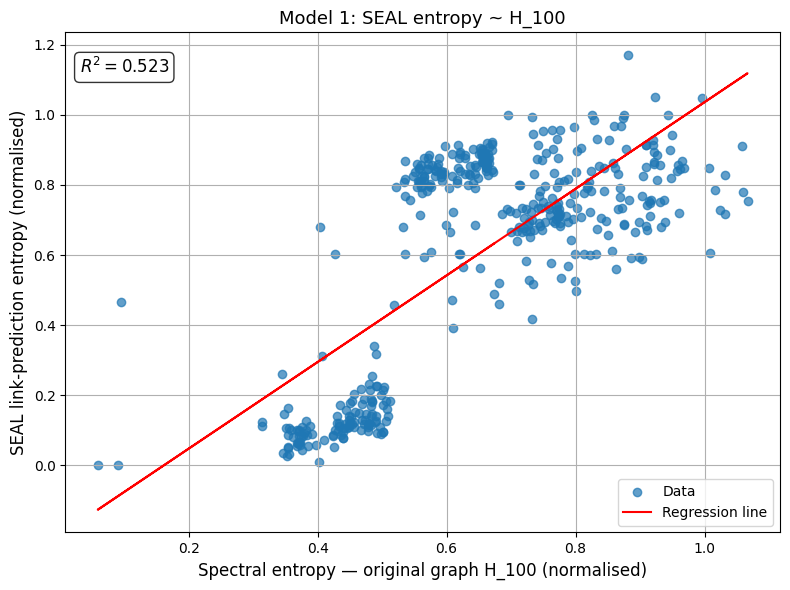

In [2]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Model 1: spectral entropy of original graph (H_100) only → predict SEAL entropy
X = sm.add_constant(df[['H_100']])
y = df['SEAL_entropy']

model1 = sm.OLS(y, X).fit()
print(model1.summary())

plt.figure(figsize=(8, 6))
plt.scatter(df['H_100'], y, alpha=0.7, label='Data')
plt.plot(df['H_100'], model1.fittedvalues, color='red', label='Regression line')
plt.xlabel('Spectral entropy — original graph H_100 (normalised)', fontsize=12)
plt.ylabel('SEAL link-prediction entropy (normalised)', fontsize=12)
plt.title('Model 1: SEAL entropy ~ H_100', fontsize=13)
plt.text(
    0.02, 0.95,
    rf'$R^2 = {model1.rsquared:.3f}$',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
import statsmodels.api as sm

# Models adding coarsened levels one at a time, always starting from H_100
portion_subsets = [
    ['H_100'],
    ['H_100', 'H_80'],
    ['H_100', 'H_80', 'H_60'],
    ['H_100', 'H_80', 'H_60', 'H_40'],
    ['H_100', 'H_80', 'H_60', 'H_40', 'H_20'],
]

y = df['SEAL_entropy']
results = []

for predictors in portion_subsets:
    X = sm.add_constant(df[predictors])
    model = sm.OLS(y, X).fit()
    for var, coef, pval in zip(model.params.index, model.params.values, model.pvalues.values):
        results.append({
            'Model':              str(predictors),
            'Variable':           var,
            'Coefficient':        coef,
            'P-Value':            pval,
            'R²':                 model.rsquared,
            'R² Adjusted':        model.rsquared_adj,
            'No. Observations':   int(model.nobs),
            'Prob (F-statistic)': model.f_pvalue,
        })

results_df = pd.DataFrame(results)
results_df[['Coefficient', 'P-Value', 'Prob (F-statistic)', 'R²', 'R² Adjusted']] = \
    results_df[['Coefficient', 'P-Value', 'Prob (F-statistic)', 'R²', 'R² Adjusted']].round(5)

print(results_df[['Model', 'Variable', 'No. Observations',
                   'Coefficient', 'P-Value', 'R²', 'R² Adjusted']].to_string(index=False))

                                    Model Variable  No. Observations  Coefficient  P-Value      R²  R² Adjusted
                                ['H_100']    const               431     -0.19962  0.00000 0.52274      0.52163
                                ['H_100']    H_100               431      1.23577  0.00000 0.52274      0.52163
                        ['H_100', 'H_80']    const               431     -0.32716  0.00000 0.69501      0.69358
                        ['H_100', 'H_80']    H_100               431     -1.17089  0.00000 0.69501      0.69358
                        ['H_100', 'H_80']     H_80               431      2.53228  0.00000 0.69501      0.69358
                ['H_100', 'H_80', 'H_60']    const               431     -0.35226  0.00000 0.70181      0.69971
                ['H_100', 'H_80', 'H_60']    H_100               431     -1.03954  0.00000 0.70181      0.69971
                ['H_100', 'H_80', 'H_60']     H_80               431      1.77874  0.00000 0.70181      

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro

def plot_residuals_by_domain(X, y, df_metadata, model_name='Model', y_limits=None):
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()

    df_res = df_metadata[['domain']].copy()
    df_res['Fitted']   = model.fittedvalues.values
    df_res['Residual'] = model.resid.values

    grouped = df_res.groupby('domain')['Residual'].agg(['mean', 'std', 'count']).reset_index()
    print(f'\n{model_name} — Residual Summary by Domain:')
    print(grouped.to_string(index=False))

    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df_res, x='domain', y='Residual', hue='domain',
                palette='pastel', fliersize=0, dodge=False, legend=False)
    sns.stripplot(data=df_res, x='domain', y='Residual',
                  color='black', jitter=0.0, size=4, alpha=0.5)
    plt.axhline(0, linestyle='--', color='red', linewidth=1)
    plt.ylabel('Residuals', fontsize=13)
    plt.xlabel('Domain', fontsize=13)
    plt.xticks(rotation=30, ha='right', fontsize=11)
    if y_limits:
        plt.ylim(y_limits)
    plt.grid(True, axis='y', linestyle=':', linewidth=0.5)
    plt.title(f'{model_name}: Residuals by Domain', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'Shapiro-Wilk test ({model_name}):')
    for domain, grp in df_res.groupby('domain'):
        stat, p = shapiro(grp['Residual'])
        print(f'  {domain:20s}  p = {p:.4f}')


Model 1 — Residual Summary by Domain:
        domain      mean      std  count
    Biological -0.014435 0.130534    142
      Economic  0.265321 0.118351    117
 Informational  0.031053 0.257258      8
        Social -0.203355 0.079744    123
 Technological  0.015698 0.054462     16
Transportation -0.179190 0.159563     25


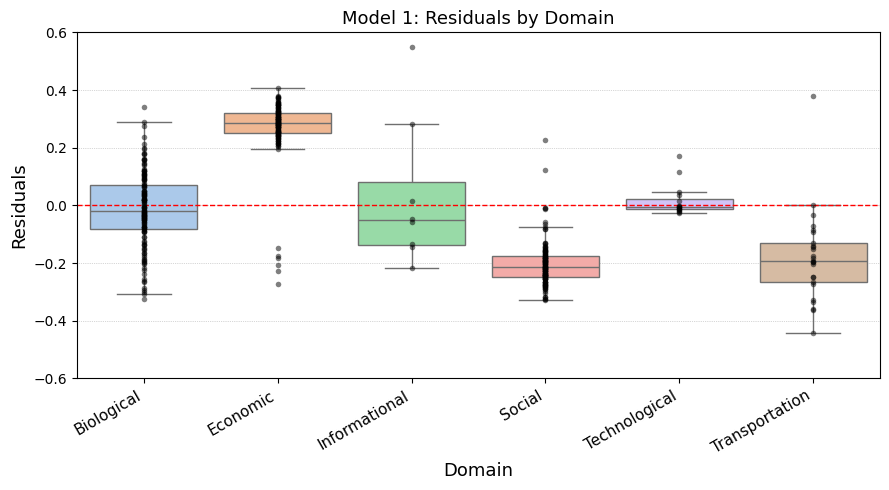

Shapiro-Wilk test (Model 1):
  Biological            p = 0.5909
  Economic              p = 0.0000
  Informational         p = 0.0773
  Social                p = 0.0000
  Technological         p = 0.0002
  Transportation        p = 0.0052

Model 5 — Residual Summary by Domain:
        domain      mean      std  count
    Biological  0.018030 0.162145    142
      Economic  0.093974 0.087924    117
 Informational  0.074179 0.327429      8
        Social -0.116154 0.090160    123
 Technological  0.146178 0.064438     16
Transportation -0.088024 0.172953     25


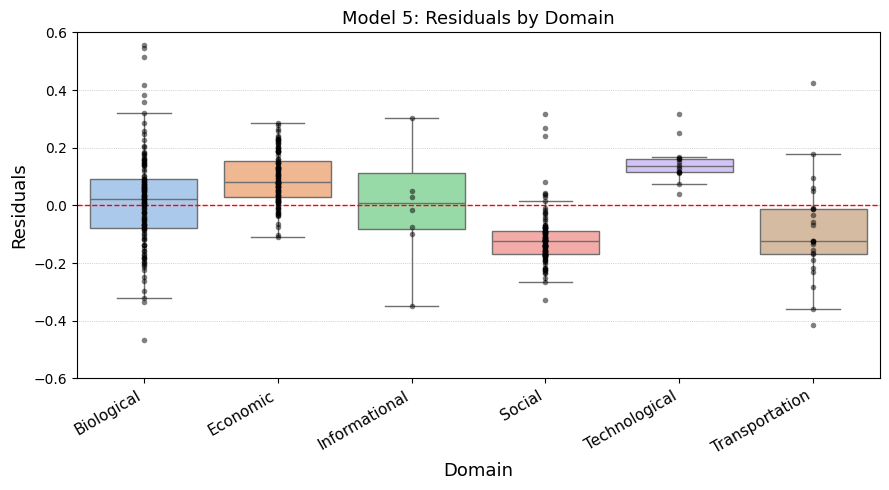

Shapiro-Wilk test (Model 5):
  Biological            p = 0.0015
  Economic              p = 0.1879
  Informational         p = 0.2205
  Social                p = 0.0000
  Technological         p = 0.0371
  Transportation        p = 0.2356


In [5]:
y = df['SEAL_entropy']

# Model 1: H_100 only (original graph)
plot_residuals_by_domain(df[['H_100']], y, df, model_name='Model 1', y_limits=(-0.6, 0.6))

# Model 5: full multiscale (H_100 + all coarsened levels)
plot_residuals_by_domain(df[['H_100', 'H_80', 'H_60', 'H_40', 'H_20']], y, df,
                         model_name='Model 5', y_limits=(-0.6, 0.6))

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error

X_cv = df[['H_100', 'H_80', 'H_60', 'H_40', 'H_20']].values
y_cv = df['SEAL_entropy'].values

lr  = LinearRegression()
kf  = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores  = cross_val_score(lr, X_cv, y_cv, cv=kf, scoring='r2')
mse_scores = cross_val_score(lr, X_cv, y_cv, cv=kf,
                              scoring=make_scorer(mean_squared_error))

print('5-fold cross-validation — Model 5 (H_100 + H_80 + H_60 + H_40 + H_20 → SEAL entropy)')
print(f'R²  scores: {r2_scores.round(4)}')
print(f'Mean R²:    {r2_scores.mean():.4f}  ±  {r2_scores.std():.4f}')
print(f'MSE scores: {mse_scores.round(4)}')
print(f'Mean MSE:   {mse_scores.mean():.4f}  ±  {mse_scores.std():.4f}')

5-fold cross-validation — Model 5 (H_100 + H_80 + H_60 + H_40 + H_20 → SEAL entropy)
R²  scores: [0.8041 0.7551 0.6887 0.7289 0.6962]
Mean R²:    0.7346  ±  0.0421
MSE scores: [0.0198 0.022  0.0306 0.0278 0.0287]
Mean MSE:   0.0258  ±  0.0041


In [ ]:
import statsmodels.api as sm

portion_subsets = [
    ['H_100'],
    ['H_100', 'H_80'],
    ['H_100', 'H_80', 'H_60'],
    ['H_100', 'H_80', 'H_60', 'H_40'],
    ['H_100', 'H_80', 'H_60', 'H_40', 'H_20'],
]

y = df['SEAL_entropy']
# y = df['SEAL_auc']
results = []

for predictors in portion_subsets:
    X = sm.add_constant(df[predictors])
    model = sm.OLS(y, X).fit()
    for var, coef, pval in zip(model.params.index, model.params.values, model.pvalues.values):
        results.append({
            'Model':              str(predictors),
            'Variable':           var,
            'Coefficient':        round(coef,  5),
            'P-Value':            round(pval,  5),
            'R²':                 round(model.rsquared,     5),
            'R² Adjusted':        round(model.rsquared_adj, 5),
            'No. Observations':   int(model.nobs),
            'Prob (F-statistic)': model.f_pvalue,
        })

results_df = pd.DataFrame(results)

# ── LaTeX table ──────────────────────────────────────────────────────────────
def fmt_pval(p):
    if p < 1e-4: return r'{\scriptsize ($<10^{-4}$)}'
    if p < 1e-3: return r'{\scriptsize ($<10^{-3}$)}'
    return rf'{{\scriptsize (${p:.3f}$)}}'

def fmt_pval_summary(p):
    if p < 1e-10: return r'\scriptsize $<10^{-10}$'
    if p < 1e-4:  return r'\scriptsize $<10^{-4}$'
    if p < 1e-3:  return r'\scriptsize $<10^{-3}$'
    return rf'\scriptsize ${p:.4f}$'

def latex_var(name):
    if name.startswith('H_'):   return f'$H_{{{name[2:]}}}$'
    if name == 'const':         return r'$\mathit{const}$'
    return rf'$\mathit{{{name}}}$'

models   = [str(s) for s in portion_subsets]
all_vars = list(dict.fromkeys(results_df['Variable'].tolist()))

rows = []
for var in all_vars:
    coef_row = [latex_var(var)]
    pval_row = ['']
    for m in models:
        sub = results_df[(results_df['Model'] == m) & (results_df['Variable'] == var)]
        if not sub.empty:
            coef_row.append(f"{sub['Coefficient'].values[0]:.4f}")
            pval_row.append(fmt_pval(sub['P-Value'].values[0]))
        else:
            coef_row.append(''); pval_row.append('')
    rows += [coef_row, pval_row]

summary_metrics = [('No. Observations', '$n$'), ('Prob (F-statistic)', r'$\mathit{Prob}(F)$'),
                   ('R²', '$R^2$'), ('R² Adjusted', r'$\mathit{Adjusted}~R^2$')]
summary_rows = []
for metric, label in summary_metrics:
    row = [label]
    for m in models:
        sub = results_df[(results_df['Model'] == m) & (results_df['Variable'] == 'const')]
        if sub.empty: row.append(''); continue
        val = sub[metric].values[0]
        if metric == 'No. Observations':        row.append(str(int(val)))
        elif metric == 'Prob (F-statistic)':    row.append(fmt_pval_summary(val).strip('{}'))
        else:                                   row.append(f'{val:.5f}')
    summary_rows.append(row)

latex = '\\begin{tabular}{l' + 'c' * len(models) + '}\n\\toprule\n'
latex += '\\textit{Model} & ' + ' & '.join(str(i+1) for i in range(len(models))) + ' \\\\\n\\midrule\n'
for row in rows:     latex += ' & '.join(row) + ' \\\\\n'
latex += '\\midrule\n'
for row in summary_rows: latex += ' & '.join(row) + ' \\\\\n'
latex += '\\bottomrule\n\\end{tabular}'
print(latex)

\begin{tabular}{lccccc}
\toprule
\textit{Model} & 1 & 2 & 3 & 4 & 5 \\
\midrule
$\mathit{const}$ & 1.1370 & 1.1758 & 1.1857 & 1.2022 & 1.2284 \\
 & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-4}$)} \\
$H_{100}$ & -0.4047 & 0.3284 & 0.2765 & 0.2326 & 0.2068 \\
 & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-3}$)} & {\scriptsize ($0.003$)} \\
$H_{80}$ &  & -0.7713 & -0.4735 & -0.4785 & -0.4591 \\
 &  & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-4}$)} & {\scriptsize ($<10^{-4}$)} \\
$H_{60}$ &  &  & -0.2540 & -0.0722 & -0.0718 \\
 &  &  & {\scriptsize ($0.002$)} & {\scriptsize ($0.478$)} & {\scriptsize ($0.480$)} \\
$H_{40}$ &  &  &  & -0.1443 & -0.1083 \\
 &  &  &  & {\scriptsize ($0.004$)} & {\scriptsize ($0.048$)} \\
$H_{20}$ &  &  &  &  & -0.0585 \\
 &  &  &  &  & {\scriptsize ($0.114$)} \\
\midr

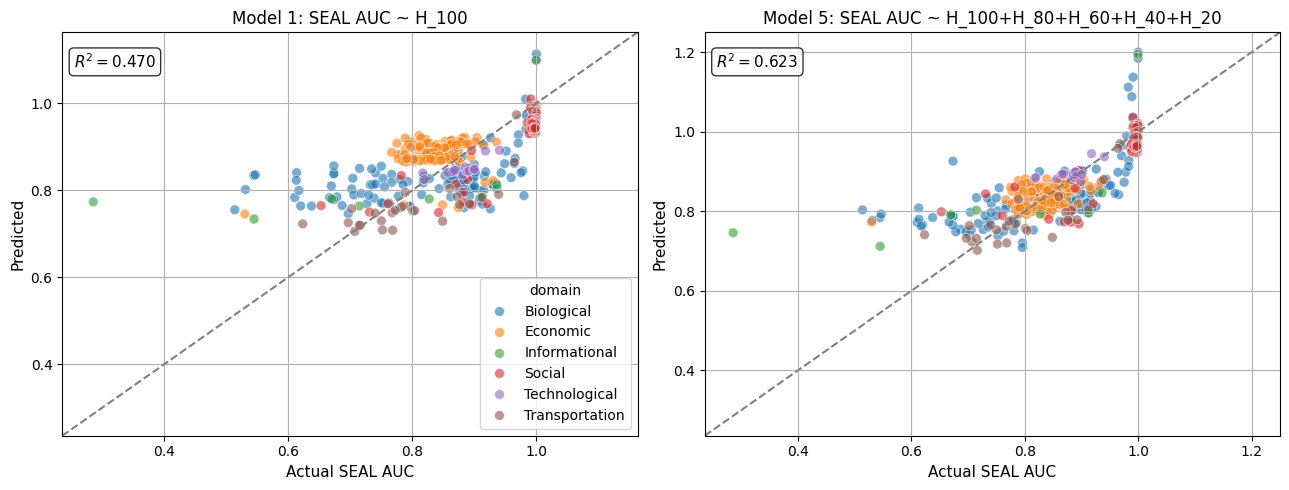

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

y = df['SEAL_auc']

X1 = sm.add_constant(df[['H_100']])
X5 = sm.add_constant(df[['H_100', 'H_80', 'H_60', 'H_40', 'H_20']])

model1 = sm.OLS(y, X1).fit()
model5 = sm.OLS(y, X5).fit()

df_plot = df.copy()
df_plot['Pred_M1'] = model1.fittedvalues.values
df_plot['Pred_M5'] = model5.fittedvalues.values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title, model in zip(axes,
                                 ['Pred_M1', 'Pred_M5'],
                                 ['Model 1: SEAL AUC ~ H_100',
                                  'Model 5: SEAL AUC ~ H_100+H_80+H_60+H_40+H_20'],
                                 [model1, model5]):
    sns.scatterplot(data=df_plot, x='SEAL_auc', y=col,
                    hue='domain', palette='tab10', ax=ax, s=50, alpha=0.6)
    lim = [min(y.min(), df_plot[col].min()) - 0.05,
           max(y.max(), df_plot[col].max()) + 0.05]
    ax.plot(lim, lim, linestyle='--', color='gray')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual SEAL AUC', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(
        0.02, 0.95,
        rf'$R^2 = {model.rsquared:.3f}$',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
    )
    ax.grid(True)
    if ax != axes[0]:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig('seal_regression_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


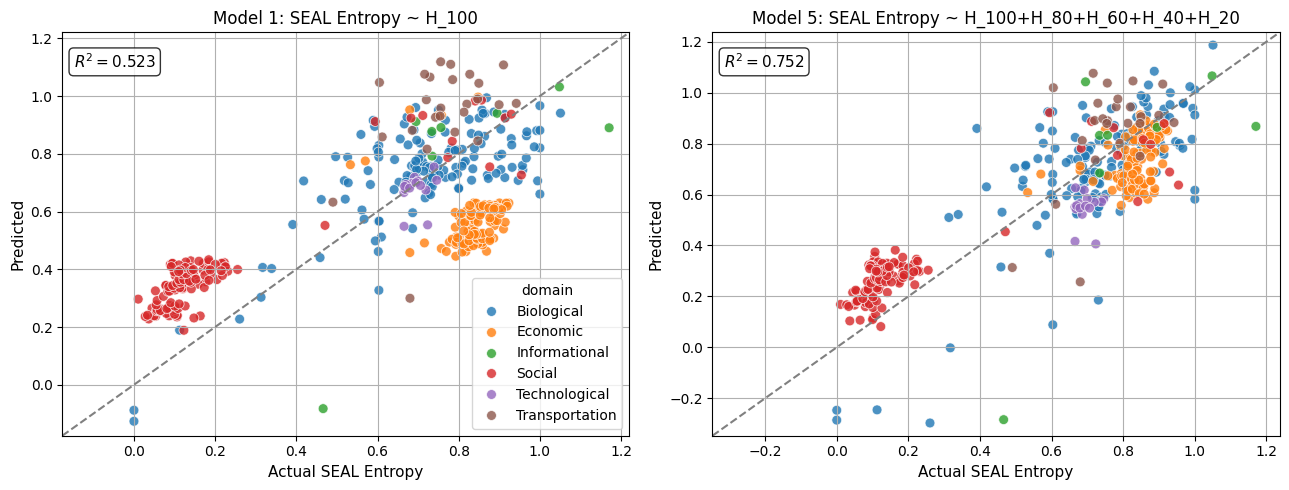

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

y = df['SEAL_entropy']

X1 = sm.add_constant(df[['H_100']])
X5 = sm.add_constant(df[['H_100', 'H_80', 'H_60', 'H_40', 'H_20']])

model1 = sm.OLS(y, X1).fit()
model5 = sm.OLS(y, X5).fit()

df_plot = df.copy()
df_plot['Pred_M1'] = model1.fittedvalues.values
df_plot['Pred_M5'] = model5.fittedvalues.values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title, model in zip(axes,
                                 ['Pred_M1', 'Pred_M5'],
                                 ['Model 1: SEAL Entropy ~ H_100',
                                  'Model 5: SEAL Entropy ~ H_100+H_80+H_60+H_40+H_20'],
                                 [model1, model5]):
    sns.scatterplot(data=df_plot, x='SEAL_entropy', y=col,
                    hue='domain', palette='tab10', ax=ax, s=50, alpha=0.8)
    lim = [min(y.min(), df_plot[col].min()) - 0.05,
           max(y.max(), df_plot[col].max()) + 0.05]
    ax.plot(lim, lim, linestyle='--', color='gray')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual SEAL Entropy', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(
        0.02, 0.95,
        rf'$R^2 = {model.rsquared:.3f}$',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
    )
    ax.grid(True)
    if ax != axes[0]:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig('seal_regression_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
